# Relatório Preliminar – Preço de Vendas de Imóveis da Terracap em Licitação Pública

### Grupo:
* Gustavo Salvador Ferraz Ferreira
* Shenia Rocha Ladeira
* Aliendres Souto Souza 
### Disciplina: Introdução ao Machine Learning 
* Prof. Dra. Roberta Moreira Wichmann
* 1º Bimestre de 2026


## 1. Descrição do problema

* Entre 2020 e 2026, foram comercializados 2998 imóveis pela empresa. O resultado de vendas revelou variações no preço de vendas de até 1.046%, em relação à avaliação inicial. Nessa pesquisa, chamaremos a variação entre o valor de avaliação e o valor de venda de ágio. Embora quanto maior o ágio, melhor o resultado financeiro para a empresa, quando a empresa não consegue estimar esse ágio, ela compromete a elaboração do fluxo de caixa futuro e se vê obrigada a adotar uma postura mais conservadora em relação à aplicação dos recursos financeiros presentes e futuros.

* Diante desse cenário, é necessário melhorar a estimativa do valor de venda futura dos imóveis, a partir da criação de um modelo de aprendizagem supervionado, que utilize informações como área do imóvel, localização e a destinação, por exemplo, para estimar o valor de venda desses imóveis. 

* O problema proposto enquadra-se em aprendizado supervisionado do tipo regressão, tendo como objetivo prever o valor final da venda do imóvel (VALOR_VENDA).


---


## 2. Descrição da Base de Dados

* A base de dados utilizada neste estudo foi construída a partir da recuperação de dados públicos relativos à venda de imóveis da Terracap em licitações públicas, no período de 2020 a 2026.

* Foram extraídos todos os registros de vendas efetivamente realizadas em licitações públicas, considerando apenas os itens imobiliários classificados na modalidade de venda — tanto à vista quanto a prazo — e excluindo-se os imóveis comercializados por meio das modalidades de concessão, aluguel ou taxa. Além disso, foram incorporadas variáveis complementares provenientes de outras bases institucionais, tais como a quantidade de propostas recebidas por cada imóvel e a situação do imóvel registrada na última vistoria obrigatória, contemplando condições como ocupado, obstruído, cercado, vago, entre outras.

* As informações relativas aos imóveis vendidos, suas características físicas e negociais — como área, destinação de uso, valor de avaliação, valor de venda, situação informada em vistoria e quantidade de propostas recebidas — possuem natureza pública. Esses dados constam nas páginas específicas de cada Edital de Venda disponibilizado no portal institucional da Terracap, bem como nos respectivos relatórios de homologação dos editais. Adicionalmente, o resultado final de cada licitação é publicado no Diário Oficial do Distrito Federal.

* Destaca-se, ainda, que foi encaminhado requerimento formal, via processo SEI, às áreas gestoras responsáveis pelas bases utilizadas, com solicitação de autorização para uso acadêmico dos dados especificados no dicionário da pesquisa. O uso das informações foi expressamente autorizado, com a ressalva de que não seriam utilizados quaisquer dados pessoais de licitantes, tais como CPF, CNPJ, contatos, endereços individualizados, dados bancários ou outras informações de natureza sensível.

* A base é relevante para o presente estudo por permitir a análise das vendas de imóveis da Terracap sob diferentes perspectivas, incluindo a evolução temporal das vendas, a distribuição por Regiões Administrativas do Distrito Federal e a influência de características dos imóveis, como dimensão, destinação de uso e situação da vistoria. Além disso, a base possibilita a análise de indicadores derivados, como o ágio absoluto — definido como a diferença entre o valor de venda e o valor de avaliação — e o ágio percentual.

* Foram criadas, para fins analíticos, as variáveis derivadas ágio absoluto e ágio percentual. Contudo, tais variáveis **não** serão utilizadas como preditoras no treinamento do modelo, uma vez que são calculadas a partir do próprio valor de venda, o que configuraria vazamento de dados e comprometeria a validade preditiva da modelagem. Também foi incluída a variável "pagamento à vista" (pgto_a_vista), destinada a identificar os imóveis em que o percentual de entrada corresponde a 100% do valor negociado.

---

In [1]:
# importação das bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# leitura da base de dados de vendas

vendas_df = pd.read_csv("base_gustavo_salvador_ferraz_ferreira.csv", sep=";", encoding="utf-8")
vendas_df.head()

,DS_CIDADE,DS_SETOR,DS_DESTINACAO_IMOVEL,ANO_VENDA,NR_EDITAL,ITEM_EDITAL,VALOR_LAUDO,PERCENTUAL_ENTRADA,VALOR_VENDA,AREA_MAX_CONSTR,AREA_BASE,AREA,QTD_OFERTAS,SITUACAO_VISTORIA,AGIO_ABSOLUTO,AGIO_PERCENTUAL,PAGTO_A_VISTA
0,BRASILIA,SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE,PURP 52 - INDUSTRIAL - FABRICAÇÃO DE PRODUTOS ...,2026,3,2,7150000,5,7211111.12,2340.0,2340.0,780.0,1,VAGO,61111.12,0.854701,0
1,CEILANDIA,SETOR INDUSTRIAL I,"UOS CSIIND 2 - COMERCIAL, PRESTAÇÃO DE SERVIÇO...",2026,3,3,84300,5,170100.00,315.0,315.0,210.0,13,CERCADO,85800.00,101.779359,0
2,GAMA,SETOR LESTE,"UOS CSII 1 - COMERCIAL, PRESTAÇÃO DE SERVIÇOS,...",2026,3,4,1590000,5,4801000.00,7200.0,6000.0,2400.0,4,VAGO,3211000.00,201.949686,0
3,GAMA,SETOR OESTE (COM),"UOS CSII 2 - COMERCIAL, PRESTAÇÃO DE SERVIÇOS,...",2026,3,5,1070000,5,2701000.00,6000.0,4000.0,2000.0,4,VAGO,1631000.00,152.429907,0
4,GUARA,SETOR RESID INDUSTRIA E ABASTECIMENTO,"UOS CSIIR 2 NO - COMERCIAL, PRESTAÇÃO DE SERVI...",2026,3,7,633000,5,633100.01,499.5,499.5,166.5,1,VAGO,100.01,0.015799,0


In [2]:
# informações sobre a base de dados

vendas_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2998 entries, 0 to 2997
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DS_CIDADE             2998 non-null   str    
 1   DS_SETOR              2998 non-null   str    
 2   DS_DESTINACAO_IMOVEL  2998 non-null   str    
 3   ANO_VENDA             2998 non-null   int64  
 4   NR_EDITAL             2998 non-null   int64  
 5   ITEM_EDITAL           2998 non-null   int64  
 6   VALOR_LAUDO           2998 non-null   int64  
 7   PERCENTUAL_ENTRADA    2998 non-null   int64  
 8   VALOR_VENDA           2998 non-null   float64
 9   AREA_MAX_CONSTR       2998 non-null   float64
 10  AREA_BASE             2998 non-null   float64
 11  AREA                  2998 non-null   float64
 12  QTD_OFERTAS           2998 non-null   int64  
 13  SITUACAO_VISTORIA     2998 non-null   str    
 14  AGIO_ABSOLUTO         2998 non-null   float64
 15  AGIO_PERCENTUAL       2998 non-n

## 3. Dicionário de Dados

- Arquivo: `dicionario_gustavo_salvador_ferraz_ferreira.xlsx`  

- O dicionário de dados (anexo em Excel), apresenta 17 variáveis, entre elas: ds_cidade (categórica nominal), ds_setor (categórica nominal), ds_destinacao_imovel  (categórica nominal), valor_laudo (numérico contínuo), percentual_entrada (numérico discreto), valor_venda (numérico contínuo), qtd_ofertas (numérico discreto).

---

## 4. Análises Descritivas Iniciais

- A variável referente a **área do imóvel**, medida em metros quadrados, apresentou valor mínimo de 4 m² e valor máximo de 164.084 m², com média de 707,97 m² e desvio padrão de 3788,79 m². Já a mediana e moda, apresentam valores de 308,16 m² e 100,00 m², respectivamente. Tais estatísticas descritivas evidenciam elevada variabilidade dos dados, indicando heterogeneidade significativa entre os imóveis analisados. Observa-se que o desvio padrão é substancialmente superior à média, o que sugere uma distribuição assimétrica, possivelmente influenciada pela presença de valores extremos. Esse comportamento indica que parte reduzida dos imóveis possui áreas muito superiores à maior parte da amostra, elevando a dispersão da variável e afastando a média dos valores mais centrais da distribuição.

- A variável **valor da venda** apresenta um valor máximo de R$ 406.670.000,00, valor mínimo de R$ 23.000,01, com média de R$ 1.517.771,03. No caso da mediana, o valor é de R$ 341.000,11, já a moda importou em R$ 130.000,00. Mediana e moda reforçam que uma parte expressiva dos imóveis são de preços populares. Seguindo a linha do tópico anterior, verifica-se uma elevada heterogeneidade nos valores dos imóveis. Linearmente, o mesmo ocorre com a variável **valor da avaliação** (VALOR_LAUDO) que possui o valor máximo de R$ 353.000.000,00, o valor mínimo de R$ 19.600,00, com média de R$ 969.104,19. Ambas as variáveis, apresentam elevado desvio padrão à direita, sendo o desvio padrão do **valor da venda** de R$ 8.278.602,61 e o desvio padrão do **valor da avaliação** de R$ 6.870.954,32, evidenciando forte dispersão e indicando a presença de imóveis de altíssimo valor que elevam a variabilidade da distribuição.

- Com relação a variável **quantidade de ofertas**, os dados demonstram menor amplitude, tendo como valor máximo 52 propostas, e valor mínimo 1 proposta. A média de propostas por imóvel é de 3.06, e o desvio padrão de 3.98. Isto sugere, que, embora muitos imóveis recebam poucas propostas, existem casos específicos de elevada concorrência. Vamos analisar se este cenário pode contribuir para a formação de ágio nas vendas, entendido como a diferença positiva entre o valor de venda e o valor de avaliação do imóvel.

- A ágio médio absoluto foi de R$ 548.666,84 e ágio médio percentual foi de 87.47%. Aqui também chama atenção a mediana do ágio absoluto de R$ 38.710,10 e do ágio percentual de 16,18%. Já em relação à moda, tanto para o ágio absoluto quanto percentual, o valor é igual a 0 (zero). A diferença expressida entre o ágio médio (87,47%) e a mediana (16,18%) reforçam as conclusões dos tópicos anteriores quanto ao tamanho, valor de venda e ágio da maioria dos imóveis vendidos pela empresa no período sob análise. Ainda assim, vale registrar que esse percentual elevado, também foi causado por um problema identificado nos dados (itens com imóveis agrupados), que será melhor explicado no item #5 - Discussão Preliminar.

- A análise do ágio é importante por permitir identificar imóveis que foram vendidos com valor da venda muito acima do valor da avaliação, além de possibilitar investigações sobre fatores associados a esse comportamento, como quantidade de ofertas, localização, destinação do imóvel e características físicas do lote.

- De forma geral, as análises descritivas, indicam que os dados não são homogêneos, mas também demonstram que o evento mais comum, é o imóvel ser vendido exatamente pelo valor da avaliação. Além disso, indicam que os imóveis têm perfis bastante distintos em termos de tamanho, valor e interesse de mercado. Tal característica, reforça a importância de complementar a análise com medidas mais robustas, como mediana, quartis e visualizações gráficas.


### 4.1 Medidas de Posição e Dispersão
Medianas:

- Mediana da Área do Imóvel (em m2): 308,16
- Mediana do Valor de Avaliação: R$ 293.000,00
- Mediana do Valor de Venda: R$ 341.000,11
- Mediana do ágio absoluto: R$ 38.710,10
- Mediana do ágio percentual: 16.18%

Quartis da Área do Imóvel:

- Q1 da Área do Imóvel (m²) (25%): 113.00
- Q2 da Área do Imóvel (m²) (50%): 308.16
- Q3 da Área do Imóvel (m²) (75%): 700.00

Quartis Valor da Avaliação:

- Q1 Valor da Avaliação (25%): R$ 133.000,00
- Q2 Valor da Avaliação (50%): R$ 293.000,00
- Q3 Valor da Avaliação (75%): R$ 523.250,00

Quartis Valor da Venda: 

- Q1 Valor da Avaliação (25%): R$ 161.500,00
- Q2 Valor da Avaliação (50%): R$ 341.000,11
- Q3 Valor da Avaliação (75%): R$ 752.000,00

Quartis do Ágio Absoluto: 

- Q1 Ágio Absoluto (25%): R$ 8.725,00
- Q2 Ágio Absoluto (50%): R$ 38.710,10
- Q3 Ágio Absoluto (75%): R$ 143.000,00

Quartis do Ágio Percentual: 

- Q1 Ágio Percentual (25%): 3.36%
- Q2 Ágio Percentual (50%): 16.18%
- Q3 Ágio Percentual (75%): 46.48%

Coeficiente de variação:

- Área do Imóvel: 535.16%
- Valor do Laudo: 709.00%
- Valor da Venda: 545.44%
- Qtd. de Ofertas: 130.12%
- Ágio Absoluto: 413.06%
- Ágio Percentual: 387.84%

---

In [3]:
# Análises estatísticas descritivas para as colunas numéricas:

# 1) Valores máximos, mínimos, médias e desvios padrão

# AREA DO IMÓVEL
print(f"Maior área de imóvel (em m²): {vendas_df['AREA'].max():.2f}")
print(f"Menor área de imóvel (em m²): {vendas_df['AREA'].min():.2f}")
print(f"Média área de imóvel (em m²): {vendas_df['AREA'].mean():.2f}")
print(f"Desvio Padrão área de imóvel (em m²): {vendas_df['AREA'].std():.2f}")

# VALOR DE AVALIACAO
print(f"Maior Valor de Avaliaçao: {vendas_df['VALOR_LAUDO'].max():.2f}")
print(f"Menor Valor de Avaliação: {vendas_df['VALOR_LAUDO'].min():.2f}")
print(f"Média do Valor da Avaliação: {vendas_df['VALOR_LAUDO'].mean():.2f}")
print(f"Desvio Padrão do Valor da Avaliação: {vendas_df['VALOR_LAUDO'].std():.2f}")

# VALOR DE VENDA
print(f"Maior Valor de Venda: {vendas_df['VALOR_VENDA'].max():.2f}")
print(f"Menor Valor de Venda: {vendas_df['VALOR_VENDA'].min():.2f}")
print(f"Média do Valor da Venda: {vendas_df['VALOR_VENDA'].mean():.2f}")
print(f"Desvio Padrão do Valor da Venda: {vendas_df['VALOR_VENDA'].std():.2f}")

# QUANTIDADE DE OFERTAS
print(f"Maior Qtd de Ofertas: {vendas_df['QTD_OFERTAS'].max():.2f}")
print(f"Menor Qtd de Ofertas: {vendas_df['QTD_OFERTAS'].min():.2f}")
print(f"Média da Qtd de Ofertas: {vendas_df['QTD_OFERTAS'].mean():.2f}")
print(f"Desvio Padrão da Qtd de Ofertas: {vendas_df['QTD_OFERTAS'].std():.2f}")

# AGIO ABSOLUTO
print(f"Maior Ágio Absoluto: {vendas_df['AGIO_ABSOLUTO'].max():.2f}")
print(f"Menor Ágio Absoluto: {vendas_df['AGIO_ABSOLUTO'].min():.2f}")
print(f"Média do Ágio Absoluto: {vendas_df['AGIO_ABSOLUTO'].mean():.2f}")
print(f"Desvio Padrão do Ágio Absoluto: {vendas_df['AGIO_ABSOLUTO'].std():.2f}")

# AGIO PERCENTUAL
print(f"Maior Ágio Percentual: {vendas_df['AGIO_PERCENTUAL'].max():.2f}%")
print(f"Menor Ágio Percentual: {vendas_df['AGIO_PERCENTUAL'].min():.2f}%")
print(f"Média do Ágio Percentual: {vendas_df['AGIO_PERCENTUAL'].mean():.2f}%")
print(f"Desvio Padrão do Ágio Percentual: {vendas_df['AGIO_PERCENTUAL'].std():.2f}%")

# 2) Medianas

mediana_area = vendas_df["AREA"].median()
mediana_valor_laudo = vendas_df["VALOR_LAUDO"].median()
mediana_valor_venda = vendas_df["VALOR_VENDA"].median()
agio_mediano_abs = vendas_df["AGIO_ABSOLUTO"].median()
agio_mediano_pct = vendas_df["AGIO_PERCENTUAL"].median()

print(f"Mediana da Área do Imóvel (em m2): {mediana_area:,.2f}")
print(f"Mediana do Valor de Avaliação: {mediana_valor_laudo:,.2f}")
print(f"Mediana do Valor de Venda: {mediana_valor_venda:,.2f}")
print(f"Ágio mediano absoluto: {agio_mediano_abs:,.2f}")
print(f"Ágio mediano percentual: {agio_mediano_pct:.2f}%")

# 3) Quartil

quartis_area = vendas_df["AREA"].quantile([0.25, 0.50, 0.75])
quartis_valor_laudo = vendas_df["VALOR_LAUDO"].quantile([0.25, 0.50, 0.75])
quartis_valor_venda = vendas_df["VALOR_VENDA"].quantile([0.25, 0.50, 0.75])
quartis_agio_percentual = vendas_df["AGIO_PERCENTUAL"].quantile([0.25, 0.50, 0.75])
quartis_agio_absoluto = vendas_df["AGIO_ABSOLUTO"].quantile([0.25, 0.50, 0.75])

print(f"Quartis da Área do Imóvel (em m2): {quartis_area}")
print(f"Quartis do Valor de Avaliação: {quartis_valor_laudo}")
print(f"Quartis do Valor de Venda: {quartis_valor_venda}")
print(f"Quartis do Ágio Percentual: {quartis_agio_percentual}")
print(f"Quartis do Ágio Absoluto: {quartis_agio_absoluto}")

# 4) Coeficiente de variação = (desvio padrão / média) * 100

cv_area = (vendas_df["AREA"].std() / vendas_df["AREA"].mean()) * 100
cv_valor_laudo = (vendas_df["VALOR_LAUDO"].std() / vendas_df["VALOR_LAUDO"].mean()) * 100
cv_valor_venda = (vendas_df["VALOR_VENDA"].std() / vendas_df["VALOR_VENDA"].mean()) * 100
cv_qtd_ofertas = (vendas_df["QTD_OFERTAS"].std() / vendas_df["QTD_OFERTAS"].mean()) * 100
cv_agio_absoluto = (vendas_df["AGIO_ABSOLUTO"].std() / vendas_df["AGIO_ABSOLUTO"].mean()) * 100
cv_agio_percentual = (vendas_df["AGIO_PERCENTUAL"].std() / vendas_df["AGIO_PERCENTUAL"].mean()) * 100

print(f"Coeficiente de variação (em m2): {cv_area:.2f}%")
print(f"Coeficiente de variação do Valor de Avaliação: {cv_valor_laudo:.2f}%")
print(f"Coeficiente de variação do Valor de Venda: {cv_valor_venda:.2f}%")
print(f"Coeficiente de variação da Qtd de Ofertas: {cv_qtd_ofertas:.2f}%")
print(f"Coeficiente de variação do Ágio Absoluto: {cv_agio_absoluto:.2f}%")
print(f"Coeficiente de variação do Ágio Percentual: {cv_agio_percentual:.2f}%")

Maior área de imóvel (em m²): 164084.00
Menor área de imóvel (em m²): 4.00
Média área de imóvel (em m²): 707.97
Desvio Padrão área de imóvel (em m²): 3788.79
Maior Valor de Avaliaçao: 353000000.00
Menor Valor de Avaliação: 19600.00
Média do Valor da Avaliação: 969104.19
Desvio Padrão do Valor da Avaliação: 6870954.32
Maior Valor de Venda: 406670000.00
Menor Valor de Venda: 23000.01
Média do Valor da Venda: 1517771.03
Desvio Padrão do Valor da Venda: 8278602.61
Maior Qtd de Ofertas: 52.00
Menor Qtd de Ofertas: 1.00
Média da Qtd de Ofertas: 3.06
Desvio Padrão da Qtd de Ofertas: 3.98
Maior Ágio Absoluto: 53670000.00
Menor Ágio Absoluto: 0.00
Média do Ágio Absoluto: 548666.84
Desvio Padrão do Ágio Absoluto: 2266324.82
Maior Ágio Percentual: 3638.78%
Menor Ágio Percentual: 0.00%
Média do Ágio Percentual: 87.47%
Desvio Padrão do Ágio Percentual: 339.24%
Mediana da Área do Imóvel (em m2): 308.16
Mediana do Valor de Avaliação: 293,000.00
Mediana do Valor de Venda: 341,000.11
Ágio mediano absol

### 4.2 Análise de correlações

Os resultados da análise de correlação indicam que a variável VALOR_LAUDO apresentou correlação extremamente forte e positiva com a variável alvo VALOR_VENDA (r = 0,97), evidenciando que, na base de dados analisada, o valor de avaliação do imóvel está quase linearmente associado ao valor efetivo de venda. Antecipando o tratamento dos dados que será realizado na etapa seguinte, verificamos que essa correlação sobe para 0.99 (item #5 - Discussão preliminar). Esse resultado é consistente com os dados obtidos nas estatísticas descritivas, que indicaram que grande parte dos imóveis são vendidos sem ágio, ou seja, pelo valor de avaliação.

Tal resultado da correlação acima, pode comprometer a modelagem preditiva, demonstrando que essa variável concentra grande parte do poder de previsão do modelo. Dessa forma, o desempenho preditivo obtido pode refletir, em larga medida, a proximidade conceitual entre o valor de avaliação e o valor final de venda, reduzindo a capacidade de o modelo identificar a contribuição efetiva das demais variáveis independentes.

Sendo assim, após a análise das correlações, resta evidenciado que a variável VALOR_LAUDO pode introduzir um viés relevante na construção do modelo, em razão de sua associação excessivamente elevada com a variável resposta. Por esse motivo, faremos sua retirada da etapa de modelagem preditiva, com o objetivo de evitar que o modelo fique excessivamente dependente dessa informação e de permitir uma avaliação mais consistente da influência das demais características dos imóveis sobre o VALOR_VENDA.

Além disso, observam-se correlações também elevadas entre VALOR_VENDA e as variáveis AREA_BASE (r = 0,92), AREA_MAX_CONSTR (r = 0,83) e AREA (r = 0,81), o que sugere que atributos físicos do imóvel possuem relevante associação com o preço final negociado. 

Em contrapartida, observou-se que a variável QTD_OFERTAS apresentou coeficiente de correlação de -0,0085 com o valor da venda, valor extremamente próximo de zero. Esse resultado sugere que a quantidade de ofertas, de forma isolada, não possui relação linear significativa com o preço final de venda dos imóveis analisados.

In [4]:
# Analisar correlação entre as variáveis numéricas e a variável "VALOR_VENDA"

colunas = [
    "VALOR_LAUDO",
    "AREA_MAX_CONSTR",
    "AREA_BASE",
    "AREA",
    "QTD_OFERTAS",
    "AGIO_ABSOLUTO",
    "AGIO_PERCENTUAL",
    "PERCENTUAL_ENTRADA",
    "PAGTO_A_VISTA",
    "VALOR_VENDA"   # target Y
]

# cria um dataframe apenas com as colunas numéricas relevantes para a análise de correlação
df_corr = vendas_df[colunas].copy()

# calcula e imprime na tela a matriz de correlação
matriz_corr = df_corr.corr(method="pearson")
display(matriz_corr)

# correlação de todas as variáveis com a target
corr_com_y = matriz_corr["VALOR_VENDA"].sort_values(ascending=False)
corr_com_y_df = corr_com_y.reset_index()
corr_com_y_df.columns = ["Variavel", "Correlacao_com_VALOR_VENDA"]

display(corr_com_y_df)

,VALOR_LAUDO,AREA_MAX_CONSTR,AREA_BASE,AREA,QTD_OFERTAS,AGIO_ABSOLUTO,AGIO_PERCENTUAL,PERCENTUAL_ENTRADA,PAGTO_A_VISTA,VALOR_VENDA
VALOR_LAUDO,1.000000,0.855314,0.951719,0.836680,-0.012406,0.519818,-0.012832,0.181562,0.009751,0.972269
AREA_MAX_CONSTR,0.855314,1.000000,0.950048,0.948708,-0.026760,0.442269,-0.007642,0.114110,-0.011590,0.830956
AREA_BASE,0.951719,0.950048,1.000000,0.946466,-0.015398,0.489392,-0.003774,0.124455,-0.009351,0.923868
AREA,0.836680,0.948708,0.946466,1.000000,-0.016183,0.452813,-0.007567,0.119368,-0.006913,0.818376
QTD_OFERTAS,-0.012406,-0.026760,-0.015398,-0.016183,1.000000,0.006551,0.020520,-0.008970,-0.012445,-0.008504
AGIO_ABSOLUTO,0.519818,0.442269,0.489392,0.452813,0.006551,1.000000,0.649292,0.176105,-0.005034,0.705188
AGIO_PERCENTUAL,-0.012832,-0.007642,-0.003774,-0.007567,0.020520,0.649292,1.000000,-0.015402,-0.013109,0.167099
PERCENTUAL_ENTRADA,0.181562,0.114110,0.124455,0.119368,-0.008970,0.176105,-0.015402,1.000000,0.866550,0.198901
PAGTO_A_VISTA,0.009751,-0.011590,-0.009351,-0.006913,-0.012445,-0.005034,-0.013109,0.866550,1.000000,0.006715
VALOR_VENDA,0.972269,0.830956,0.923868,0.818376,-0.008504,0.705188,0.167099,0.198901,0.006715,1.000000


,Variavel,Correlacao_com_VALOR_VENDA
0,VALOR_VENDA,1.000000
1,VALOR_LAUDO,0.972269
2,AREA_BASE,0.923868
3,AREA_MAX_CONSTR,0.830956
4,AREA,0.818376
5,AGIO_ABSOLUTO,0.705188
6,PERCENTUAL_ENTRADA,0.198901
7,AGIO_PERCENTUAL,0.167099
8,PAGTO_A_VISTA,0.006715
9,QTD_OFERTAS,-0.008504


### 4.3 Exploração Gráfica


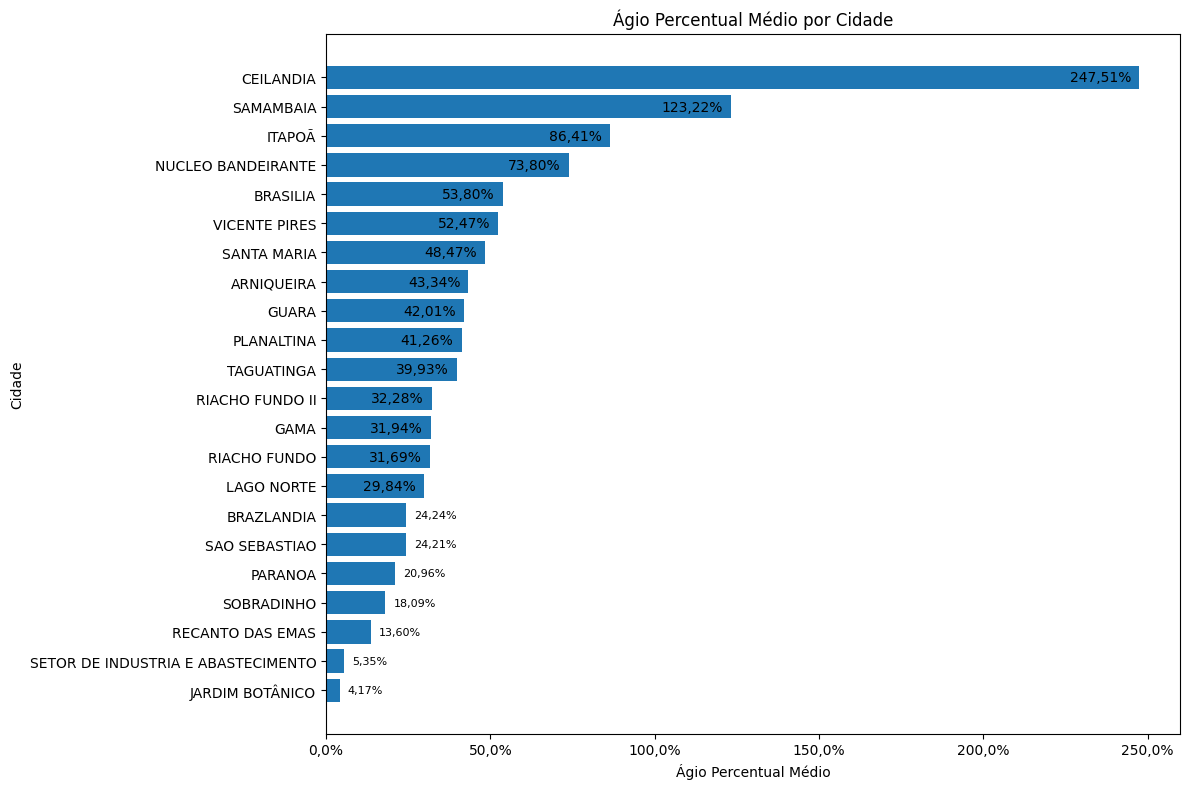

In [5]:
# Análise do Ágio Percentual Médio por Cidade

agio_por_cidade = (
    vendas_df.groupby("DS_CIDADE")["AGIO_PERCENTUAL"]
    .mean()
    .reset_index()
    .sort_values("AGIO_PERCENTUAL", ascending=True)
)

def formatar_percentual(valor, pos=None):
    return f"{valor:.1f}%".replace(".", ",")

plt.figure(figsize=(12, 8))
ax = plt.gca()

barras = ax.barh(agio_por_cidade["DS_CIDADE"], agio_por_cidade["AGIO_PERCENTUAL"])

ax.set_title("Ágio Percentual Médio por Cidade")
ax.set_xlabel("Ágio Percentual Médio")
ax.set_ylabel("Cidade")

ax.grid(False)
plt.grid(False)

ax.xaxis.set_major_formatter(FuncFormatter(formatar_percentual))

max_valor = agio_por_cidade["AGIO_PERCENTUAL"].max()

for barra in barras:
    largura = barra.get_width()
    y = barra.get_y() + barra.get_height() / 2
    texto = f"{largura:.2f}%".replace(".", ",")

    if largura > max_valor * 0.12:
        ax.text(
            largura - max_valor * 0.01,
            y,
            texto,
            va="center",
            ha="right"
        )
    else:
        ax.text(
            largura + max_valor * 0.01,
            y,
            texto,
            va="center",
            ha="left",
            fontsize=8
        )

plt.tight_layout()
plt.show()

Gráfico demonstra a região da Ceilândia com o maior percentual de ágio

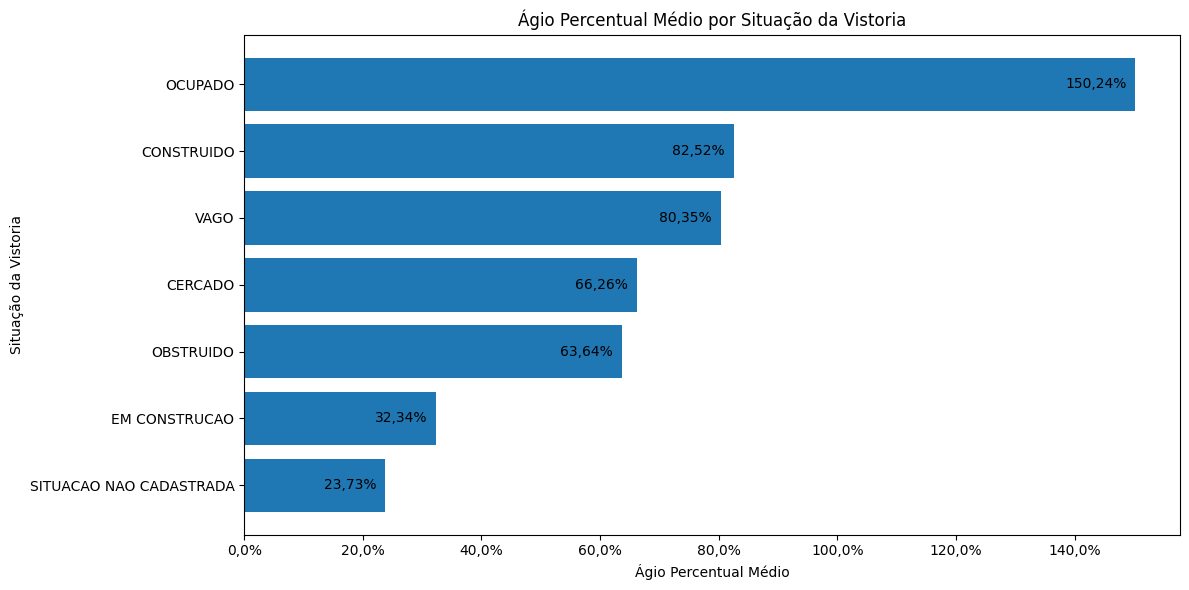

In [6]:
# Ágio Percentual Médio por Situação da Vistoria

agio_por_vistoria = (
    vendas_df.groupby("SITUACAO_VISTORIA")["AGIO_PERCENTUAL"]
    .mean()
    .reset_index()
    .sort_values("AGIO_PERCENTUAL", ascending=True)
)


plt.figure(figsize=(12, 6))
ax = plt.gca()

barras = ax.barh(
    agio_por_vistoria["SITUACAO_VISTORIA"],
    agio_por_vistoria["AGIO_PERCENTUAL"]
)

ax.set_title("Ágio Percentual Médio por Situação da Vistoria")
ax.set_xlabel("Ágio Percentual Médio")
ax.set_ylabel("Situação da Vistoria")

ax.grid(False)
plt.grid(False)

ax.xaxis.set_major_formatter(FuncFormatter(formatar_percentual))

max_valor = agio_por_vistoria["AGIO_PERCENTUAL"].max()

for barra in barras:
    largura = barra.get_width()
    y = barra.get_y() + barra.get_height() / 2
    texto = f"{largura:.2f}%".replace(".", ",")

    if largura > max_valor * 0.12:
        ax.text(
            largura - max_valor * 0.01,
            y,
            texto,
            va="center",
            ha="right"
        )
    else:
        ax.text(
            largura + max_valor * 0.01,
            y,
            texto,
            va="center",
            ha="left",
            fontsize=8
        )

plt.tight_layout()
plt.show()

Gráfico demonstra que imóveis em situação de vistoria "Ocupados" possuem os maiores ágios

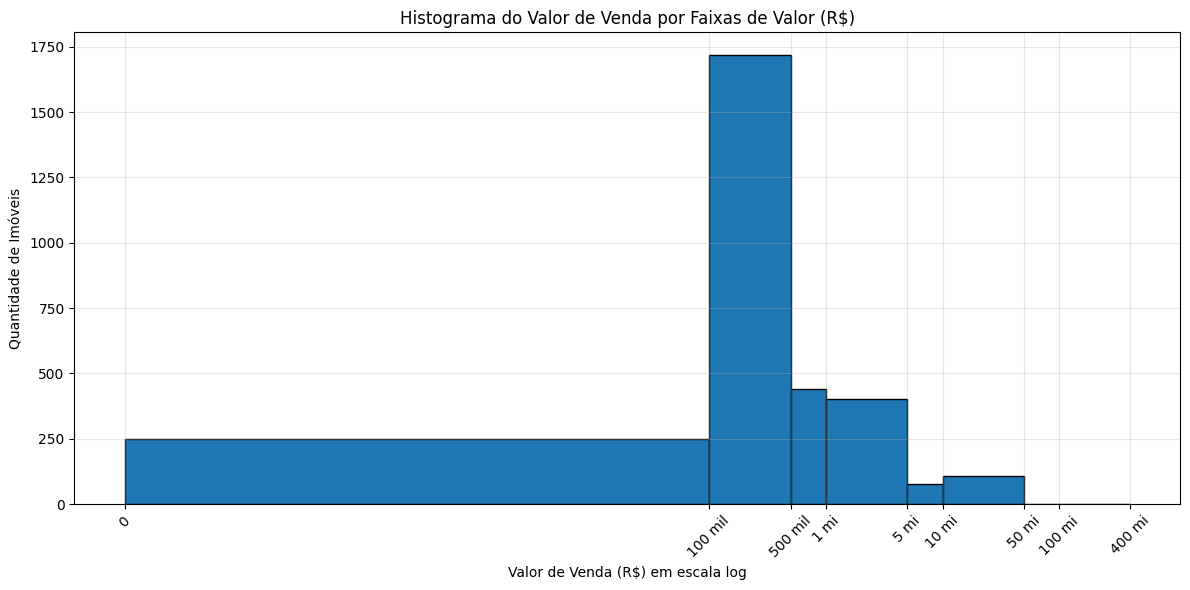

In [7]:
# Gráfico das vendas por faixa de valor

# criação de faixas no valor original

faixas_valor = [
    0,
    100_000,
    500_000,
    1_000_000,
    5_000_000,
    10_000_000,
    50_000_000,
    100_000_000,
    400_000_000
]

# converter as faixas para escala log
faixas_log = np.log1p(faixas_valor)

# dados transformados em log
dados_log = np.log1p(vendas_df["VALOR_VENDA"].dropna())

plt.figure(figsize=(12, 6))
plt.hist(dados_log, bins=faixas_log, edgecolor="black")

plt.title("Histograma do Valor de Venda por Faixas de Valor (R$)")
plt.xlabel("Valor de Venda (R$) em escala log")
plt.ylabel("Quantidade de Imóveis")
plt.grid(True, alpha=0.3)

# mostrar no eixo X os valores originais, não o log
plt.xticks(
    faixas_log,
    [
        "0",
        "100 mil",
        "500 mil",
        "1 mi",
        "5 mi",
        "10 mi",
        "50 mi",
        "100 mi",
        "400 mi"
    ],
    rotation=45
)

plt.tight_layout()
plt.show()

O gráfico demonstra que a maioria dos imóveis são vendidos entre as faixas de 100 e 500 mil.

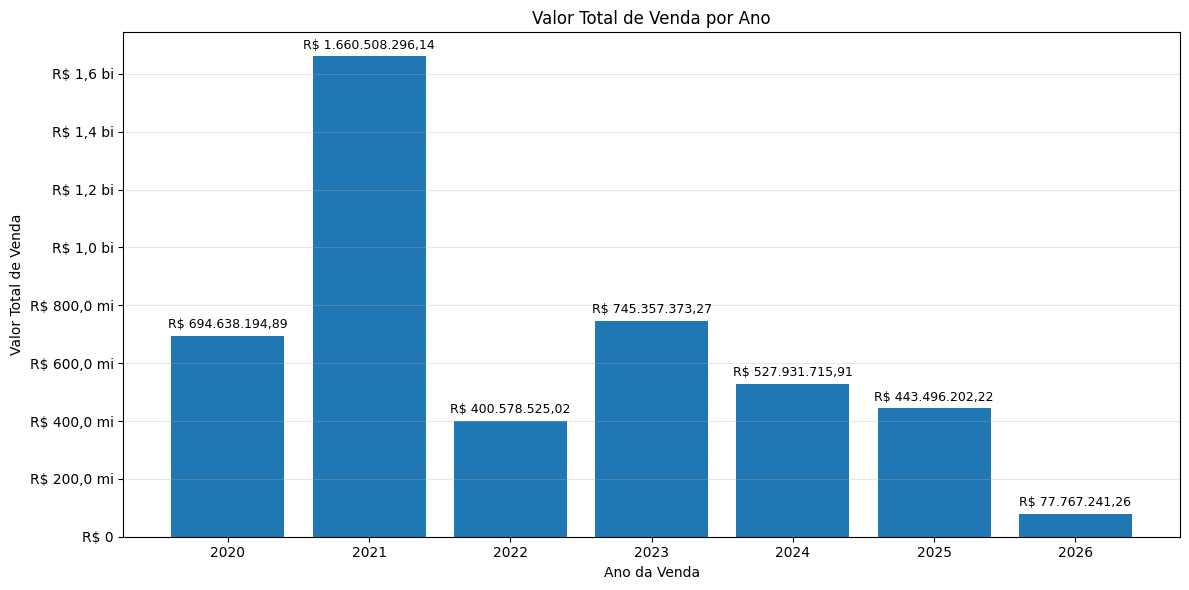

In [8]:
# Analisar a evolução do valor total de venda por ano

# cria um dataframe com o valor total de venda por ano
venda_por_ano = (
    vendas_df.groupby("ANO_VENDA")["VALOR_VENDA"]
    .sum()
    .reset_index()
    .sort_values("ANO_VENDA")
)

# função para formatar os valores em reais de forma abreviada (mil, mi, bi) no eixo Y
def formatar_real_abreviado(valor, pos=None):
    if valor >= 1_000_000_000:
        return f"R$ {valor/1_000_000_000:.1f} bi".replace(".", ",")
    elif valor >= 1_000_000:
        return f"R$ {valor/1_000_000:.1f} mi".replace(".", ",")
    elif valor >= 1_000:
        return f"R$ {valor/1_000:.1f} mil".replace(".", ",")
    else:
        return f"R$ {valor:.0f}".replace(".", ",")

# função para formatar os valores em reais completos no topo de cada barra
def formatar_real_completo(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


plt.figure(figsize=(12, 6))
barras = plt.bar(venda_por_ano["ANO_VENDA"], venda_por_ano["VALOR_VENDA"])

plt.title("Valor Total de Venda por Ano")
plt.xlabel("Ano da Venda")
plt.ylabel("Valor Total de Venda")
plt.grid(axis="y", alpha=0.3)

# eixo Y abreviado
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_real_abreviado))

# rótulo completo no topo de cada barra
max_valor = venda_por_ano["VALOR_VENDA"].max()

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + max_valor * 0.01,
        formatar_real_completo(altura),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

Em 2021 houve a venda do imóvel de maior valor na base: R$ 406.670.000,00

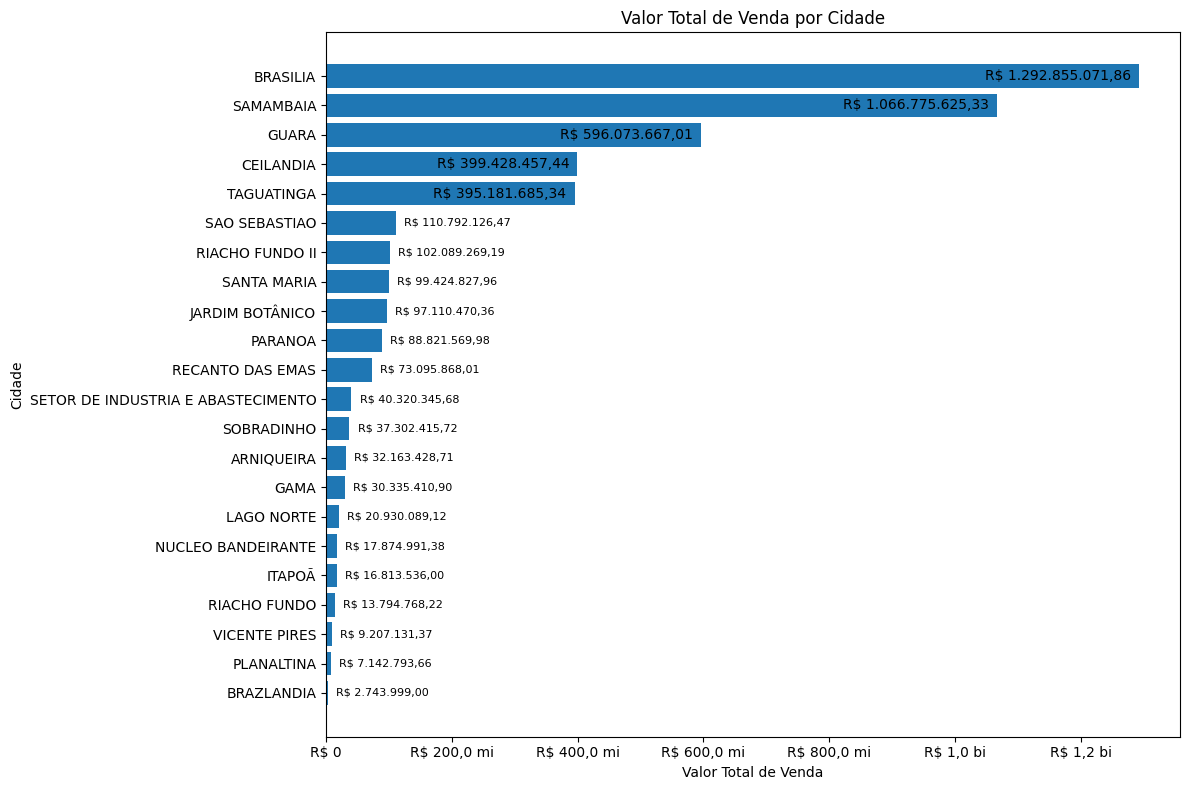

In [9]:
# analisar o valor total de venda por cidade

# cria o dataframe com o valor total de venda por cidade, ordenado do menor para o maior valor
venda_por_cidade = (
    vendas_df.groupby("DS_CIDADE")["VALOR_VENDA"]
    .sum()
    .reset_index()
    .sort_values("VALOR_VENDA", ascending=True)
)

plt.figure(figsize=(12, 8))
ax = plt.gca()

barras = ax.barh(venda_por_cidade["DS_CIDADE"], venda_por_cidade["VALOR_VENDA"])

ax.set_title("Valor Total de Venda por Cidade")
ax.set_xlabel("Valor Total de Venda")
ax.set_ylabel("Cidade")

# formata eixo X
ax.xaxis.set_major_formatter(FuncFormatter(formatar_real_abreviado))

max_valor = venda_por_cidade["VALOR_VENDA"].max()

for barra in barras:
    largura = barra.get_width()
    y = barra.get_y() + barra.get_height() / 2
    texto = formatar_real_completo(largura)

    # barras maiores: texto dentro
    if largura > max_valor * 0.12:
        ax.text(
            largura - max_valor * 0.01,
            y,
            texto,
            va="center",
            ha="right"
        )
    # barras menores: texto fora
    else:
        ax.text(
            largura + max_valor * 0.01,
            y,
            texto,
            va="center",
            ha="left",
            fontsize=8
        )

plt.tight_layout()
plt.show()

Gráfico mostra que Brasília e Samambaia historicamente, concentram os maiores valores de vendas.

## 5. Discussão Preliminar
Na discussão preliminar, destacamos:  

- Questões de qualidade/entendimento dos dados:

  - Durante a etapa de entendimento da base, identificou-se a necessidade de aprofundamento conceitual, junto à área de negócio, acerca dos três campos distintos relacionados à área do imóvel. Esse esclarecimento mostra-se relevante, uma vez que tais medidas são explicitamente informadas nos editais de licitação, compondo, portanto, o conjunto de informações disponíveis aos interessados no momento da decisão de compra. Assim, compreender adequadamente o significado de cada uma dessas variáveis é fundamental para a correta interpretação dos dados e para sua utilização na modelagem preditiva.

    Nesse contexto, as medidas foram compreendidas da seguinte forma:
      - Área (m2): área do imóvel/lote, registrada em cartório
      - Área Base (m2): área de construção básica do imóvel/lote, sem incidência de ODIR - Outorga Onerosa de Direito de Construir
      - Área Máxima de Construção (m2): área de máxima de construção do imóvel/lote, cuja diferença entre ela e a area básica, haverá incidência de ODIR - Outorga Onerosa de Direito de Construir.

  - Foram identificados 14 registros nos quais as variáveis relacionadas às áreas de construção, AREA_MAX_CONSTR e AREA_BASE, apresentavam valor igual a zero. A análise desses casos indicou que se tratam de apartamentos, tipologia em que, diferentemente dos lotes, não há distinção prática entre a área registrada em cartório e áreas adicionais de potencial construtivo. Assim, entendeu-se que a ausência de valores nessas variáveis não representa, necessariamente, inconsistência material do imóvel, mas sim uma característica específica desse tipo de unidade. Dessa forma, como procedimento de tratamento e padronização da base, optaremos por preencher os campos AREA_MAX_CONSTR e AREA_BASE com o valor da variável área do imóvel registrada em cartório, de modo a preservar a coerência das informações e evitar impactos indevidos na etapa de modelagem preditiva.
  
  - Também foi identificada, na base de dados, a existência de vendas referentes a itens de edital compostos por imóveis agrupados, prática adotada pela empresa em determinadas alienações, nas quais um mesmo item é formado por mais de um imóvel e comercializado de forma conjunta. Essa característica pode introduzir distorções na modelagem preditiva, uma vez que os imóveis pertencentes ao mesmo item compartilham um único valor de venda, correspondente ao valor total negociado pelo conjunto, enquanto mantêm valores de avaliação individuais. Em termos analíticos, essa estrutura pode gerar viés na base, pois associa a múltiplos registros de imóveis distintos um mesmo valor de saída, comprometendo a consistência entre variáveis explicativas e variável alvo. Diante disso, optaremos por excluir esses casos da análise, com o objetivo de preservar a coerência dos dados utilizados na modelagem. Essa etapa de tratamento resultará na remoção de 145 imóveis da base. Estes registros atualmente impactam de forma significativa as variáveis de AGIO_ABSOLUTO e AGIO_PERCENTUAL.

  - Correlação extremamente elevada da variável VALOR_LAUDO com a variável alvo VALOR_VENDA (r = 0.9722), indicando forte associação linear entre o valor de avaliação do imóvel e o valor efetivamente praticado na venda. Removendo os 145 registros de itens agrupados, mencionados no parágrafo anterior, essa correlação subiu para 0.99. Em razão dessa elevada proximidade, a variável VALOR_LAUDO concentra grande parte do poder de previsão do modelo, reduzindo a capacidade de avaliar, de forma mais clara, a contribuição das demais variáveis explicativas. Assim, na etapa subsequente, optaremos por desenvolver a modelagem principal sem a variável VALOR_LAUDO. 

- Também verificamos que alguns imóveis possuem o valor de venda, muito superiores ao valor da avaliação. Procuramos entender este fenômeno, mas as variáveis AGIO_ABSOLUTO e AGIO_PERCENTUAL, possuem coeficiente de correlação de baixa magnitude com todas as variáveis analisadas, especialmente com a quantidade de ofertas (r = 0,0205), bem como com AREA, AREA_BASE e AREA_MAX_CONSTR, cujos coeficientes permaneceram próximos de zero. Esses achados sugerem que os maiores ágios proporcionais observados na base não são explicados, de forma linear, pelas variáveis analisadas, indicando a possível influência de fatores não capturados diretamente no conjunto de dados, como características específicas do imóvel, percepção de oportunidade pelos licitantes ou aspectos contextuais do processo licitatório.

- A variável QTD_OFERTAS, embora relevante sob a ótica negocial por representar a concorrência incidente sobre o imóvel, não apresentou associação linear significativa com a variável alvo VALOR_VENDA (r = -0,0085). Adicionalmente, sob o ponto de vista temporal, uma vez que, a depender do momento de aplicação do modelo, a quantidade de ofertas pode ainda não estar disponível, configurando uso de informação futura. Assim, considerando sua baixa capacidade explicativa na análise de correlação e a possibilidade de inconsistência quanto à disponibilidade da informação no momento da predição, a variável será excluída da modelagem preditiva.

- Com relação à variável DS_DESTINACAO_IMOVEL, responsável por indicar os tipos de uso permitidos para cada imóvel, observou-se que a base de dados apresenta 52 destinações distintas, o que caracteriza elevada diversidade categórica. A partir da análise individual de cada registro da base de destinações, verificou-se a possibilidade de consolidar essas categorias em quatro classes funcionais mais amplas, correspondentes a Uso Residencial, Uso Comercial, Uso Industrial e Uso Institucional, as quais podem ocorrer de forma isolada ou simultânea em um mesmo imóvel. Diante disso, na etapa subsequente de preparação dos dados, optaremos por representar essa informação por meio da criação de quatro variáveis binárias, assumindo os valores 1 (sim) e 0 (não), de acordo com a presença ou ausência de cada tipo de uso permitido. Essa estratégia permitirá incorporar de forma mais estruturada e interpretável a informação de destinação do imóvel, além de eliminar a necessidade de aplicação de One-Hot Encoding sobre a variável original.
---

In [10]:
# colunas que definem a duplicidade: mesmo ano, mesmo edital e mesmo item do edital (item de edital com imoveis agrupados)
cols = ["ANO_VENDA", "NR_EDITAL", "ITEM_EDITAL"]

# máscara: True para linhas que aparecem em duplicidade (em qualquer posição do grupo)
mask_dup = vendas_df.duplicated(subset=cols, keep=False)

# remove TODAS as linhas duplicadas desses grupos
tabela_sem_dups = vendas_df.loc[~mask_dup].copy()

# Foram encontrados 145 itens que constavam como items agrupados, de um total de 2998, restando 2853 registros 
print("Linhas originais:", len(vendas_df))
print("Linhas de itens agrupados:", mask_dup.sum())


Linhas originais: 2998
Linhas de itens agrupados: 145


## 5. Próximos Passos

- Após a realização dos ajustes identificados na etapa anterior, a base de dados estará mais adequada para a condução dos experimentos de treino e teste dos modelos preditivos. A variável alvo definida para o estudo será o valor final da venda (VALOR_VENDA).

- As variáveis AGIO_ABSOLUTO e AGIO_PERCENTUAL, embora úteis na etapa de análise exploratória, serão retiradas da modelagem, por serem derivadas diretamente do valor final da venda, o que poderia gerar vazamento de dados e comprometer a validade preditiva dos resultados.

- A variável QTD_OFERTAS, também será removida do modelo, por considerarmos que, no momento da predição, ela ainda não estará disponível.

- Adicionalmente, considerando que a variável VALOR_LAUDO apresentou associação extremamente forte com a variável alvo e concentra elevado poder explicativo, optou-se por adotar duas estratégias de modelagem para fins comparativos. Na modelagem principal, serão realizados testes de regressão sem a variável VALOR_LAUDO, com o objetivo de verificar a capacidade do modelo em predizer o valor da venda a partir das demais características disponíveis. Paralelamente, também serão conduzidos testes com a inclusão de VALOR_LAUDO, a fim de comparar o desempenho obtido e avaliar o impacto dessa variável sobre a capacidade preditiva e a interpretabilidade do modelo. Dessa forma, será possível analisar em que medida o modelo mantém poder de predição mesmo na ausência de uma variável de elevada correlação com a variável resposta.

## Referências 
- Fontes de dados  (bases de dados da Terracap)
- Site da Terracap que possui informações de licitações (https://www.terracap.df.gov.br)  
- Exemplo de um edital, link direto. Informações dos itens a partir da página 5 (https://www.terracap.df.gov.br/uploads/edicts/69a0c2ddeafb1.pdf)
- Exemplo de publicação de dados dos vencedores da Licitação 02/2026 - página 77 (AVISO DE HOMOLOGAÇÃO E CONVOCAÇÃO DE LICITAÇÃO
REFERENTE AO EDITAL Nº 02/2026–IMÓVEIS) (https://dodf.df.gov.br/dodf/jornal/visualizar-pdf?pasta=2026|02_Fevereiro|DODF%20038%2027-02-2026|&arquivo=DODF%20038%2027-02-2026%20INTEGRA.pdf)